***Name:*** TSION LEGESSE  
***Date:*** 8/10/2026  
***Student ID:*** GSR/1433/18

***Data science and cloud computing for Bioinformatics ASSIGNMENT 6***

In [1]:
%pip install -q GEOparse gseapy scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, re, random, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, ConfusionMatrixDisplay,
                             classification_report, confusion_matrix, f1_score, precision_score,
                             PrecisionRecallDisplay, recall_score, roc_auc_score, RocCurveDisplay)
from sklearn.model_selection import (GridSearchCV, StratifiedGroupKFold, StratifiedKFold,
                                     cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

GSE_ID   = "GSE15471"
DATA_DIR = "data"
OUT_DIR  = "outputs"
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

scikit-learn 1.7.2 | pandas 2.3.3 | numpy 2.3.5


In [3]:
import os, glob
for f in glob.glob(os.path.join(DATA_DIR, "GSE15471*")):
    os.remove(f); print("removed", f)

removed data\GSE15471_family.soft.gz


In [4]:
import requests, gzip

url  = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE15nnn/GSE15471/soft/GSE15471_family.soft.gz"
dest = os.path.join(DATA_DIR, "GSE15471_family.soft.gz")

with requests.get(url, stream=True, timeout=120) as r:
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))
    done = 0
    with open(dest, "wb") as fh:
        for chunk in r.iter_content(chunk_size=1 << 20):
            fh.write(chunk); done += len(chunk)
print(f"Downloaded {done/1e6:.1f} MB (server said {total/1e6:.1f} MB)")

# integrity check: this raises an error if the gzip file is truncated
with gzip.open(dest, "rb") as fh:
    while fh.read(1 << 24):
        pass
print("File is complete and readable")

Downloaded 48.1 MB (server said 48.1 MB)
File is complete and readable


In [5]:
import GEOparse
gse = GEOparse.get_GEO(filepath=dest, silent=True)
print(gse.get_metadata_attribute("title"))
print("Samples:", len(gse.gsms), "| Platforms:", list(gse.gpls.keys()))

expr = gse.pivot_samples("VALUE")   # probes x samples
print("Expression table (probes x samples):", expr.shape)

C:\Users\MY-LENOVO\anaconda3\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


Whole-Tissue Gene Expression Study of Pancreatic Ductal Adenocarcinoma
Samples: 78 | Platforms: ['GPL570']
Expression table (probes x samples): (54675, 78)


In [7]:
rows = []
for gsm_id, gsm in gse.gsms.items():
    md_ = gsm.metadata
    rows.append({
        "gsm": gsm_id,
        "title": " ".join(md_.get("title", [])),
        "source": " ".join(md_.get("source_name_ch1", [])),
        "characteristics": " | ".join(md_.get("characteristics_ch1", [])),
    })
meta = pd.DataFrame(rows).set_index("gsm")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)
meta

,title,source,characteristics
gsm,,,
GSM388076,N30162,pancreas,patient: 30162 | sample: normal
GSM388077,N30162_rep,pancreas,patient: 30162 | sample: normal
GSM388078,N40728,pancreas,patient: 40728 | sample: normal
GSM388079,N40728_rep,pancreas,patient: 40728 | sample: normal
GSM388080,N41027,pancreas,patient: 41027 | sample: normal
GSM388081,N41027_rep,pancreas,patient: 41027 | sample: normal
GSM388082,N30057,pancreas,patient: 30057 | sample: normal
GSM388083,N30068,pancreas,patient: 30068 | sample: normal
GSM388084,N30277,pancreas,patient: 30277 | sample: normal


In [8]:
print(meta["source"].value_counts())
print()
print(meta["characteristics"].value_counts().head(10))

source
pancreas    78
Name: count, dtype: int64

characteristics
patient: 30162 | sample: normal    2
patient: 40728 | sample: normal    2
patient: 41027 | sample: tumor     2
patient: 40728 | sample: tumor     2
patient: 30162 | sample: tumor     2
patient: 41027 | sample: normal    2
patient: 40899 | sample: tumor     1
patient: 30277 | sample: tumor     1
patient: 30308 | sample: tumor     1
patient: 30364 | sample: tumor     1
Name: count, dtype: int64


In [9]:
# ---- target vector (tumour = 1, normal = 0) ---------------------------------
NORMAL_PAT = r"normal|non[- ]?tumou?r|adjacent|control|healthy|benign"
TUMOR_PAT  = r"tumou?r|cancer|carcinoma|pdac|adenocarcinoma|malignant"

def label_from_text(row):
    text = " ".join([row["title"], row["source"], row["characteristics"]]).lower()
    if re.search(NORMAL_PAT, text): return 0
    if re.search(TUMOR_PAT,  text): return 1
    return np.nan

meta["y"] = meta.apply(label_from_text, axis=1)
assert meta["y"].notna().all(), "Some samples could not be labelled"
meta["y"] = meta["y"].astype(int)

# ---- patient groups (needed for leakage-free splitting) ---------------------
meta["patient"] = meta["characteristics"].str.extract(r"patient:\s*(\w+)")[0]
meta["is_replicate"] = meta["title"].str.contains("_rep", case=False)
ct = pd.crosstab(meta["patient"], meta["y"])
paired = bool(meta["patient"].notna().all() and (ct > 0).all().all())
if not paired:
    print("WARNING: treating samples as independent")
    meta["patient"] = meta.index
print("Paired design confirmed:", paired, "| patients:", meta["patient"].nunique(), "| arrays:", len(meta))
print("Arrays per patient:", meta["patient"].value_counts().value_counts().to_dict(),
      "| technical-replicate arrays:", int(meta["is_replicate"].sum()))
print("Class counts (1 = tumour):", meta["y"].value_counts().to_dict())

# ---- log2 transform if needed ------------------------------------------------
if np.nanmax(expr.values) > 50:
    print("Values look like raw intensities -> log2 transform")
    expr = np.log2(expr.clip(lower=1))
else:
    print("Values already look log2-scaled (max = %.2f)" % np.nanmax(expr.values))

# ---- assemble X, y, groups ---------------------------------------------------
X = expr.T.loc[meta.index]          # samples x probes
y = meta["y"].copy()
groups = meta["patient"].copy()
assert X.shape[0] == y.shape[0] == groups.shape[0]
print("X:", X.shape, "| y:", y.shape)

Paired design confirmed: True | patients: 36 | arrays: 78
Arrays per patient: {2: 33, 4: 3} | technical-replicate arrays: 6
Class counts (1 = tumour): {0: 39, 1: 39}
Values already look log2-scaled (max = 14.79)
X: (78, 54675) | y: (78,)


In [10]:
gpl = list(gse.gpls.values())[0]
ann = gpl.table.copy()
sym_col = next(c for c in ann.columns if c.lower().replace("_", " ") in ("gene symbol", "symbol", "gene_symbol"))
ann = ann.set_index("ID")
probe2gene = (ann[sym_col].astype(str).str.split(r"\s*///\s*").str[0]
              .replace({"nan": np.nan, "---": np.nan, "": np.nan}))
print("Probes with gene symbol: %.1f %%" % (100 * probe2gene.reindex(X.columns).notna().mean()))

Probes with gene symbol: 83.7 %


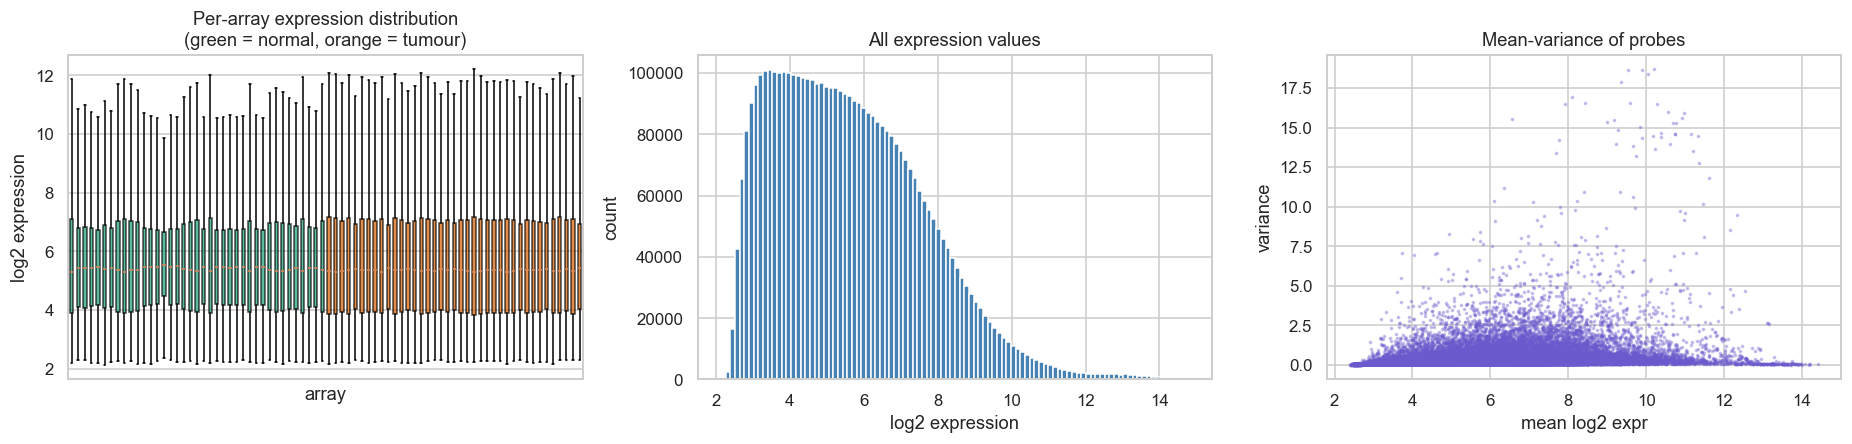

count    4264650.00
mean           5.63
std            2.01
min            2.14
25%            4.00
50%            5.39
75%            6.95
max           14.79
dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

# (a) distribution of values per array
order = y.sort_values().index
bp = axes[0].boxplot([X.loc[i].values for i in order], showfliers=False, patch_artist=True)
for patch, lab in zip(bp["boxes"], y.loc[order]):
    patch.set_facecolor("#d95f02" if lab == 1 else "#1b9e77"); patch.set_alpha(.7)
axes[0].set(title="Per-array expression distribution\n(green = normal, orange = tumour)",
            xlabel="array", ylabel="log2 expression", xticks=[])

# (b) overall value density
axes[1].hist(X.values.ravel(), bins=100, color="steelblue")
axes[1].set(title="All expression values", xlabel="log2 expression", ylabel="count")

# (c) mean-variance relationship across probes
m, v = X.mean(), X.var()
axes[2].scatter(m, v, s=2, alpha=.3, color="slateblue")
axes[2].set(title="Mean-variance of probes", xlabel="mean log2 expr", ylabel="variance")

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/eda_distributions.png"); plt.show()
print(X.stack().describe().round(2))

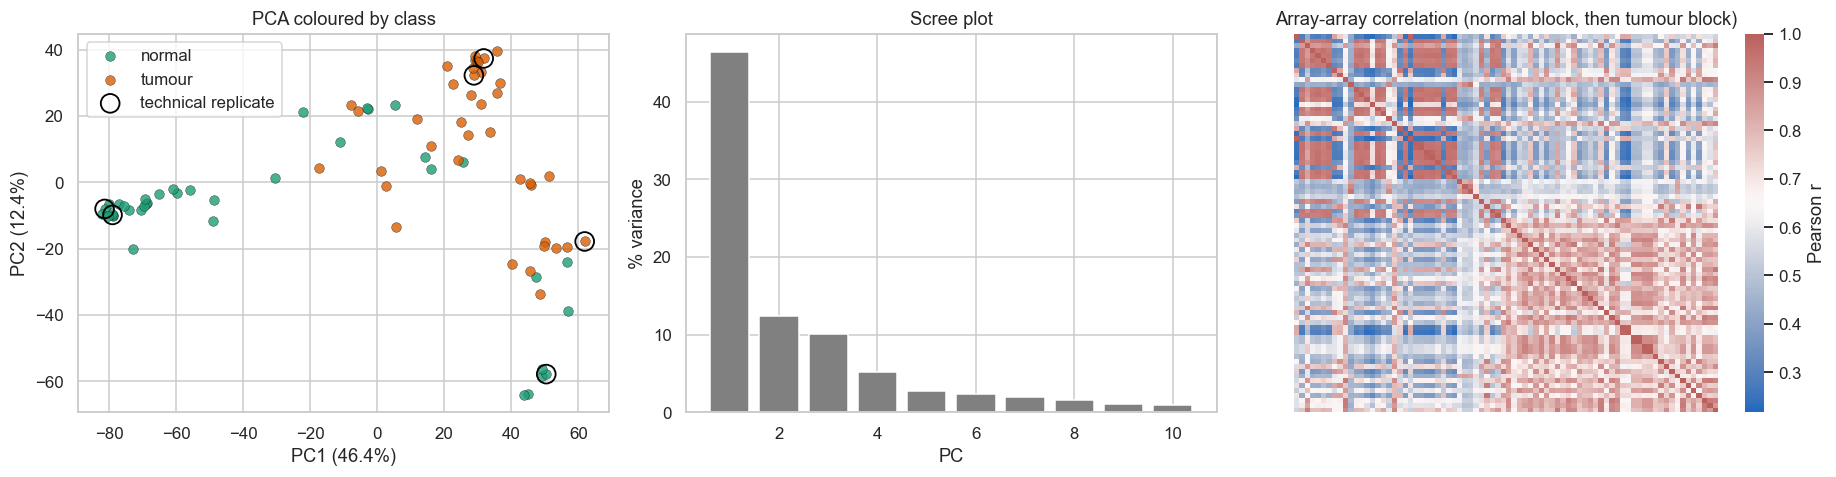

PC1: mean normal = -29.68 | mean tumour = +29.68
PC2: mean normal = -11.29 | mean tumour = +11.29
PC3: mean normal = +7.80 | mean tumour = -7.80


In [12]:
top = X.var().sort_values(ascending=False).index[:5000]
Z = StandardScaler().fit_transform(X[top])
pca = PCA(n_components=10, random_state=SEED).fit(Z)
pcs = pca.transform(Z)
ev = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for lab, name, col in [(0, "normal", "#1b9e77"), (1, "tumour", "#d95f02")]:
    mk = (y.values == lab)
    axes[0].scatter(pcs[mk, 0], pcs[mk, 1], c=col, label=name, s=40, alpha=.8, edgecolor="k", lw=.3)
rep = meta["is_replicate"].values
axes[0].scatter(pcs[rep, 0], pcs[rep, 1], s=150, facecolors="none", edgecolors="black", lw=1.2, label="technical replicate")
axes[0].set(xlabel=f"PC1 ({ev[0]:.1%})", ylabel=f"PC2 ({ev[1]:.1%})", title="PCA coloured by class")
axes[0].legend()

axes[1].bar(range(1, 11), ev * 100, color="grey")
axes[1].set(title="Scree plot", xlabel="PC", ylabel="% variance")

C = np.corrcoef(X.loc[order, top].values)
sns.heatmap(C, ax=axes[2], cmap="vlag", center=C.mean(), xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Pearson r"})
axes[2].set(title="Array-array correlation (normal block, then tumour block)")

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/eda_pca.png"); plt.show()

for k in range(3):
    print(f"PC{k+1}: mean normal = {pcs[y.values==0, k].mean():+.2f} | mean tumour = {pcs[y.values==1, k].mean():+.2f}")

In [13]:
print("PC1 AUC (unsupervised axis vs label):", round(roc_auc_score(y, pcs[:, 0]), 3))
print("PC2 AUC:", round(roc_auc_score(y, pcs[:, 1]), 3))
print("Variance explained: PC1 = %.1f%%, PC2 = %.1f%%, PC3 = %.1f%%" % tuple(100 * ev[:3]))

PC1 AUC (unsupervised axis vs label): 0.799
PC2 AUC: 0.759
Variance explained: PC1 = 46.4%, PC2 = 12.4%, PC3 = 10.0%


Total missing entries: 0 (0.0000% of matrix)
Samples with any NaN : 0
Probes  with any NaN : 0
Constant probes      : 0
Duplicate sample rows: 0
Metadata labels missing: 0

Class counts:
 y
normal    39
tumour    39
Imbalance ratio (majority/minority): 1.00


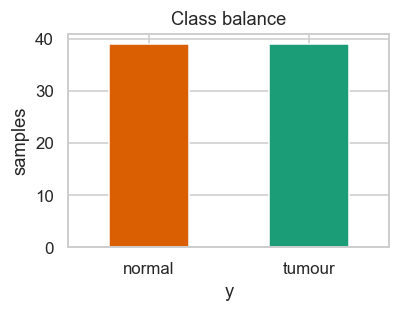

In [14]:
n_na = int(X.isna().sum().sum())
print(f"Total missing entries: {n_na} ({n_na / X.size:.4%} of matrix)")
print("Samples with any NaN :", int(X.isna().any(axis=1).sum()))
print("Probes  with any NaN :", int(X.isna().any(axis=0).sum()))
print("Constant probes      :", int((X.nunique() <= 1).sum()))
print("Duplicate sample rows:", int(X.duplicated().sum()))
print("Metadata labels missing:", int(y.isna().sum()))

vc = y.map({0: "normal", 1: "tumour"}).value_counts()
print("\nClass counts:\n", vc.to_string())
print(f"Imbalance ratio (majority/minority): {vc.max() / vc.min():.2f}")

fig, ax = plt.subplots(figsize=(3.8, 3))
vc.plot.bar(color=["#d95f02", "#1b9e77"], ax=ax, rot=0)
ax.set_ylabel("samples"); ax.set_title("Class balance")
plt.tight_layout(); plt.show()

In [15]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

assert set(g_train).isdisjoint(set(g_test)), "Patient leakage between train and test!"
print(f"train: {X_train.shape}  test: {X_test.shape}")
print("train class counts:", y_train.value_counts().to_dict(), "| test class counts:", y_test.value_counts().to_dict())
print("patients train/test:", g_train.nunique(), "/", g_test.nunique(), "(no overlap)")

train: (56, 54675)  test: (22, 54675)
train class counts: {0: 28, 1: 28} | test class counts: {0: 11, 1: 11}
patients train/test: 26 / 10 (no overlap)


In [16]:
class TopVariance(BaseEstimator, TransformerMixin):
    """Keep the k features with the highest variance (computed on training data only)."""
    def __init__(self, k=5000):
        self.k = k
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        var = np.nanvar(X, axis=0)
        self.idx_ = np.sort(np.argsort(var)[::-1][: min(self.k, X.shape[1])])
        return self
    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.idx_]

def make_pipe(clf, k_var=5000, k_best=200):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("topvar", TopVariance(k=k_var)),
        ("scale",  StandardScaler()),
        ("select", SelectKBest(f_classif, k=k_best)),
        ("clf",    clf),
    ])

def selected_probe_names(pipe, feature_names):
    idx = pipe.named_steps["topvar"].idx_[pipe.named_steps["select"].get_support(indices=True)]
    return np.asarray(feature_names)[idx]

models = {
    "Logistic Regression": make_pipe(LogisticRegression(max_iter=5000, random_state=SEED)),
    "SVM":                 make_pipe(SVC(kernel="rbf", random_state=SEED)),
    "Random Forest":       make_pipe(RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)),
}
models["Logistic Regression"]

,steps,"[('impute', ...), ('topvar', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,k,5000


In [17]:
cv5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall",
           "f1": "f1", "roc_auc": "roc_auc", "avg_precision": "average_precision"}

baseline = {}
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, groups=g_train, cv=cv5, scoring=scoring, n_jobs=1)
    baseline[name] = {m: (res[f"test_{m}"].mean(), res[f"test_{m}"].std()) for m in scoring}
    print(f"done: {name}")

baseline_df = pd.DataFrame(
    {n: {m: f"{mu:.3f} ± {sd:.3f}" for m, (mu, sd) in d.items()} for n, d in baseline.items()}
).T
baseline_df.to_csv(f"{OUT_DIR}/baseline_cv.csv")
baseline_df

done: Logistic Regression
done: SVM
done: Random Forest


,accuracy,precision,recall,f1,roc_auc,avg_precision
Logistic Regression,0.892 ± 0.024,0.913 ± 0.072,0.881 ± 0.103,0.889 ± 0.030,0.943 ± 0.016,0.946 ± 0.021
SVM,0.926 ± 0.042,0.877 ± 0.068,1.000 ± 0.000,0.933 ± 0.037,0.963 ± 0.037,0.960 ± 0.046
Random Forest,0.886 ± 0.048,0.910 ± 0.078,0.870 ± 0.108,0.883 ± 0.050,0.961 ± 0.021,0.963 ± 0.021


In [18]:
import time

grids = {
    "Logistic Regression": {
        "select__k": [50, 200, 1000],
        "clf__C": [1e-3, 1e-2, 1e-1, 1, 10],
    },
    "SVM": [
        {"select__k": [50, 200, 1000], "clf__kernel": ["linear"], "clf__C": [1e-3, 1e-2, 1e-1, 1]},
        {"select__k": [50, 200, 1000], "clf__kernel": ["rbf"], "clf__C": [0.1, 1, 10],
         "clf__gamma": ["scale", "auto"]},
    ],
    "Random Forest": {
        "select__k": [200, 1000],
        "clf__max_features": ["sqrt", 0.1],
        "clf__min_samples_leaf": [1, 3],
    },
}

searches = {}
for name, pipe in models.items():
    t0 = time.time()
    gs = GridSearchCV(pipe, grids[name], scoring="roc_auc", cv=cv5, n_jobs=1, refit=True)
    gs.fit(X_train, y_train, groups=g_train)
    searches[name] = gs
    print(f"{name:20s} best CV ROC-AUC = {gs.best_score_:.3f} | {gs.best_params_} | {time.time()-t0:.0f}s")

best_models = {n: gs.best_estimator_ for n, gs in searches.items()}

Logistic Regression  best CV ROC-AUC = 0.963 | {'clf__C': 0.01, 'select__k': 1000} | 98s
SVM                  best CV ROC-AUC = 0.980 | {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 1000} | 202s
Random Forest        best CV ROC-AUC = 0.976 | {'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'select__k': 1000} | 104s


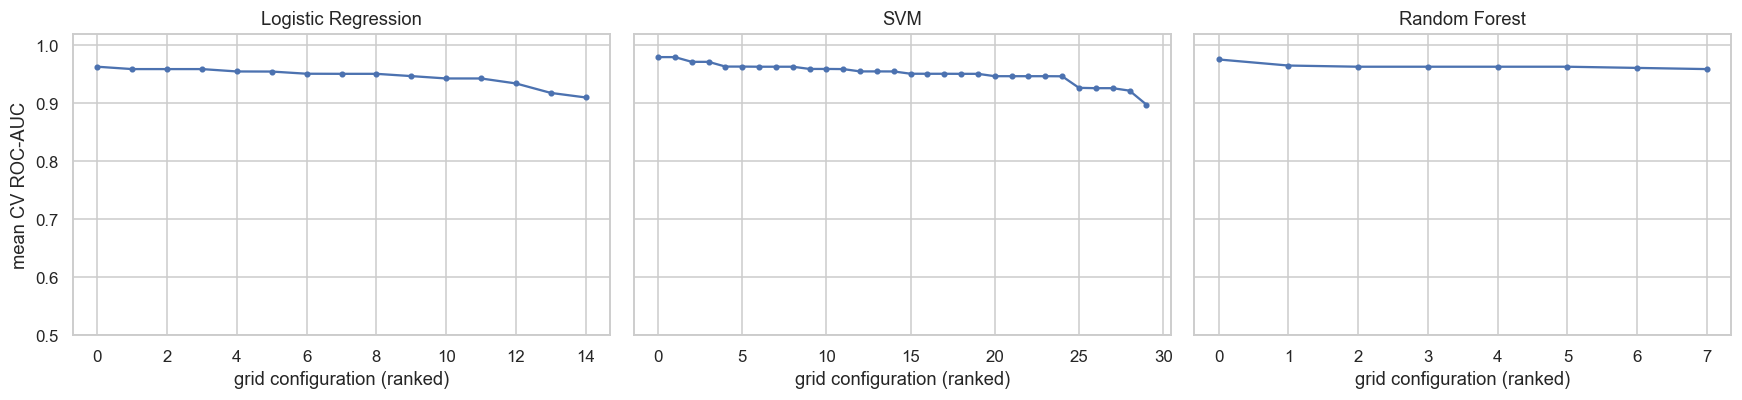

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
for ax, (name, gs) in zip(axes, searches.items()):
    r = pd.DataFrame(gs.cv_results_)
    ax.plot(np.sort(r["mean_test_score"].values)[::-1], marker="o", ms=3)
    ax.set(title=name, xlabel="grid configuration (ranked)", ylim=(0.5, 1.02))
axes[0].set_ylabel("mean CV ROC-AUC")
plt.tight_layout(); plt.show()

In [21]:
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
nested = {}
for name, pipe in models.items():
    t0 = time.time()
    aucs = []
    for tr, te in outer.split(X_train, y_train, g_train):
        gs = GridSearchCV(clone(pipe), grids[name], scoring="roc_auc",
                          cv=StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED), n_jobs=1)
        gs.fit(X_train.iloc[tr], y_train.iloc[tr], groups=g_train.iloc[tr])
        s = gs.decision_function(X_train.iloc[te]) if hasattr(gs, "decision_function") else gs.predict_proba(X_train.iloc[te])[:, 1]
        aucs.append(roc_auc_score(y_train.iloc[te], s))
    nested[name] = aucs
    print(f"{name:20s} nested ROC-AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}  folds: {np.round(aucs, 3)}  ({time.time()-t0:.0f}s)")

Logistic Regression  nested ROC-AUC = 0.949 ± 0.031  folds: [0.92  0.969 1.    0.92  0.938]  (394s)
SVM                  nested ROC-AUC = 0.903 ± 0.055  folds: [0.84  0.922 1.    0.88  0.875]  (818s)
Random Forest        nested ROC-AUC = 0.957 ± 0.027  folds: [0.96  0.969 1.    0.92  0.938]  (411s)


In [22]:
print(list(best_models.keys()))
for n, gs in searches.items():
    print(f"{n:20s} tuned CV AUC = {gs.best_score_:.3f} | {gs.best_params_}")

['Logistic Regression', 'SVM', 'Random Forest']
Logistic Regression  tuned CV AUC = 0.963 | {'clf__C': 0.01, 'select__k': 1000}
SVM                  tuned CV AUC = 0.980 | {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 1000}
Random Forest        tuned CV AUC = 0.976 | {'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'select__k': 1000}


In [23]:
def get_scores(est, Xd):
    return est.decision_function(Xd) if hasattr(est, "decision_function") else est.predict_proba(Xd)[:, 1]

def boot_auc_ci(y_true, scores, n=2000, seed=SEED):
    rng = np.random.default_rng(seed); y_true = np.asarray(y_true); out = []
    for _ in range(n):
        i = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[i])) == 2:
            out.append(roc_auc_score(y_true[i], scores[i]))
    return np.percentile(out, [2.5, 97.5])

test_rows, test_scores, test_preds = [], {}, {}
for name, est in best_models.items():
    s = get_scores(est, X_test); p = est.predict(X_test)
    test_scores[name], test_preds[name] = s, p
    lo, hi = boot_auc_ci(y_test, s)
    test_rows.append({"model": name,
                      "accuracy":  accuracy_score(y_test, p),
                      "precision": precision_score(y_test, p, zero_division=0),
                      "recall":    recall_score(y_test, p),
                      "F1":        f1_score(y_test, p),
                      "ROC-AUC":   roc_auc_score(y_test, s),
                      "AUC 95% CI (bootstrap)": f"[{lo:.2f}, {hi:.2f}]",
                      "Avg precision (PR-AUC)": average_precision_score(y_test, s)})
test_df = pd.DataFrame(test_rows).set_index("model")
test_df.round(3).to_csv(f"{OUT_DIR}/test_metrics.csv")
display(test_df.round(3))

for name in best_models:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, test_preds[name], target_names=["normal", "tumour"], digits=3, zero_division=0))

,accuracy,precision,recall,F1,ROC-AUC,AUC 95% CI (bootstrap),Avg precision (PR-AUC)
model,,,,,,,
Logistic Regression,0.909,0.909,0.909,0.909,0.959,"[0.85, 1.00]",0.954
SVM,0.909,0.846,1.000,0.917,0.934,"[0.78, 1.00]",0.907
Random Forest,0.864,0.900,0.818,0.857,0.959,"[0.85, 1.00]",0.954



=== Logistic Regression ===
              precision    recall  f1-score   support

      normal      0.909     0.909     0.909        11
      tumour      0.909     0.909     0.909        11

    accuracy                          0.909        22
   macro avg      0.909     0.909     0.909        22
weighted avg      0.909     0.909     0.909        22


=== SVM ===
              precision    recall  f1-score   support

      normal      1.000     0.818     0.900        11
      tumour      0.846     1.000     0.917        11

    accuracy                          0.909        22
   macro avg      0.923     0.909     0.908        22
weighted avg      0.923     0.909     0.908        22


=== Random Forest ===
              precision    recall  f1-score   support

      normal      0.833     0.909     0.870        11
      tumour      0.900     0.818     0.857        11

    accuracy                          0.864        22
   macro avg      0.867     0.864     0.863        22
weighted 

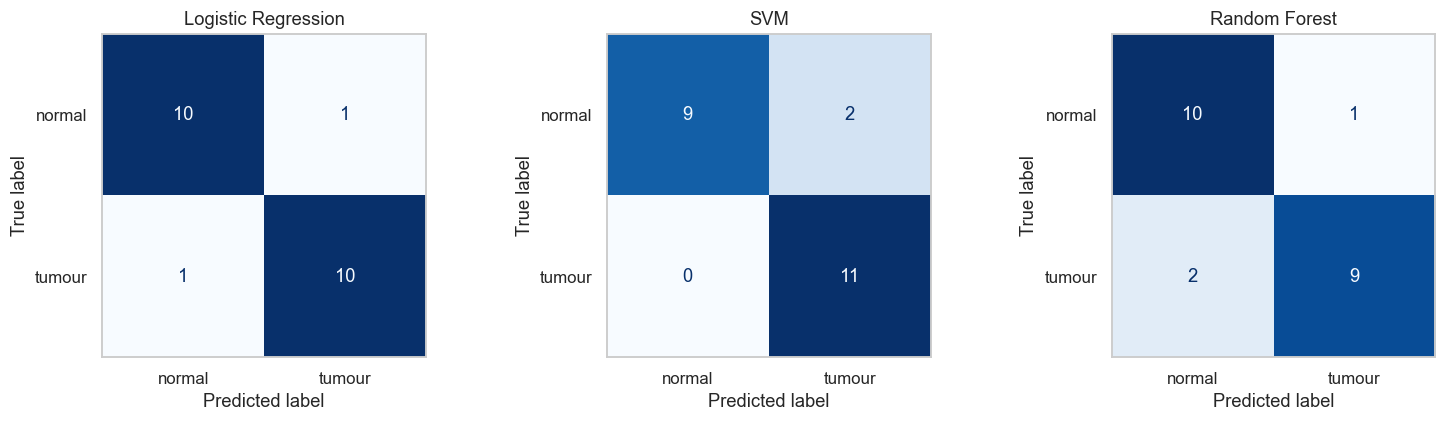

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, best_models):
    ConfusionMatrixDisplay(confusion_matrix(y_test, test_preds[name]),
                           display_labels=["normal", "tumour"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name); ax.grid(False)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_matrices.png"); plt.show()

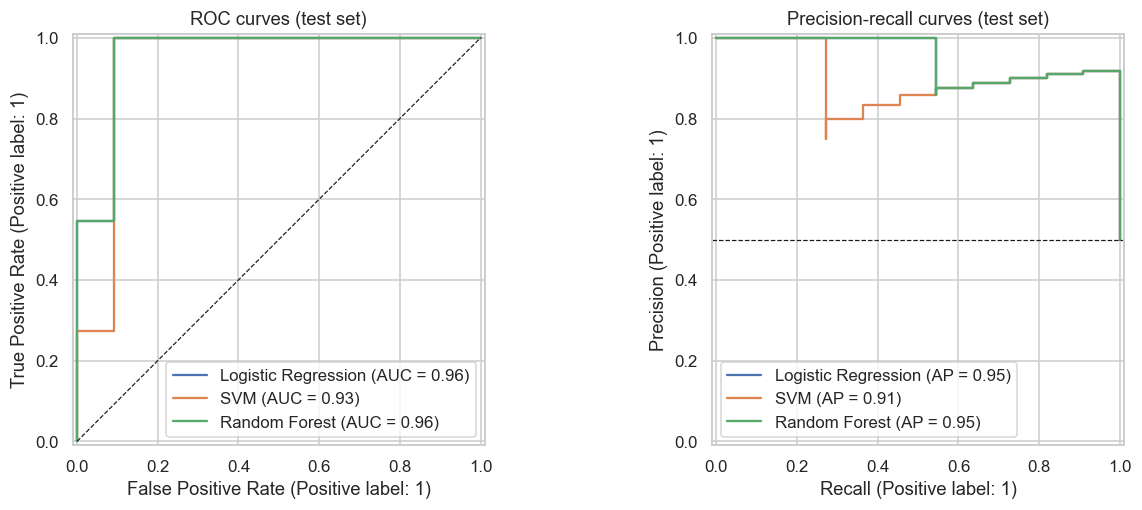

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for name in best_models:
    RocCurveDisplay.from_predictions(y_test, test_scores[name], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, test_scores[name], name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", lw=.8); axes[0].set_title("ROC curves (test set)")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=.8); axes[1].set_title("Precision-recall curves (test set)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/roc_pr_curves.png"); plt.show()

,Baseline CV AUC,Tuned CV AUC,Nested CV AUC,Nested CV SD,Test AUC,Test F1,Test recall,Test precision,Optimism (tuned CV - nested)
Logistic Regression,0.943,0.963,0.949,0.031,0.959,0.909,0.909,0.909,0.014
SVM,0.963,0.980,0.903,0.055,0.934,0.917,1.000,0.846,0.077
Random Forest,0.961,0.976,0.957,0.027,0.959,0.857,0.818,0.900,0.019


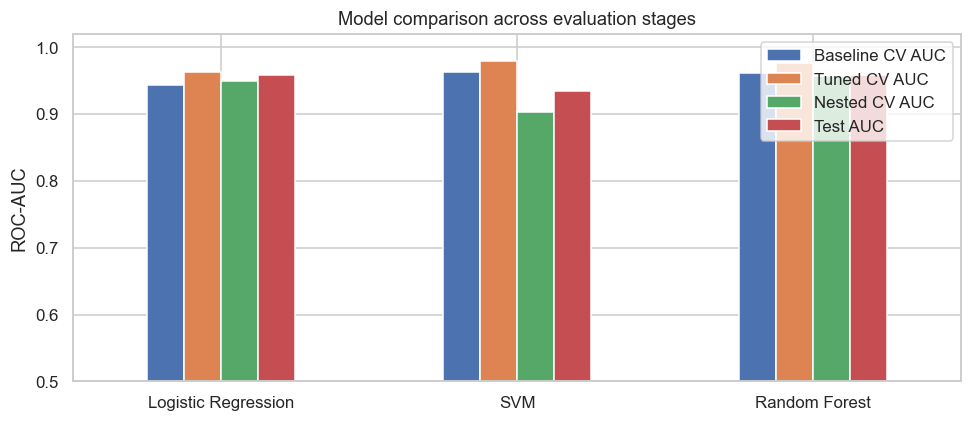

In [26]:
comparison = pd.DataFrame({
    "Baseline CV AUC":  {n: baseline[n]["roc_auc"][0] for n in models},
    "Tuned CV AUC":     {n: searches[n].best_score_ for n in models},
    "Nested CV AUC":    {n: np.mean(nested[n]) for n in models},
    "Nested CV SD":     {n: np.std(nested[n]) for n in models},
    "Test AUC":         test_df["ROC-AUC"],
    "Test F1":          test_df["F1"],
    "Test recall":      test_df["recall"],
    "Test precision":   test_df["precision"],
}).round(3)
comparison["Optimism (tuned CV - nested)"] = (comparison["Tuned CV AUC"] - comparison["Nested CV AUC"]).round(3)
comparison.to_csv(f"{OUT_DIR}/model_comparison.csv")
display(comparison)

ax = comparison[["Baseline CV AUC", "Tuned CV AUC", "Nested CV AUC", "Test AUC"]].plot.bar(figsize=(9, 4), rot=0)
ax.set_ylim(0.5, 1.02); ax.set_ylabel("ROC-AUC"); ax.set_title("Model comparison across evaluation stages")
plt.tight_layout(); plt.show()

In [27]:
gap = pd.DataFrame({
    n: {"train accuracy": accuracy_score(y_train, m.predict(X_train)),
        "train AUC":      roc_auc_score(y_train, get_scores(m, X_train)),
        "test accuracy":  accuracy_score(y_test, test_preds[n]),
        "test AUC":       roc_auc_score(y_test, test_scores[n])}
    for n, m in best_models.items()
}).T.round(3)
gap

,train accuracy,train AUC,test accuracy,test AUC
Logistic Regression,0.964,0.990,0.909,0.959
SVM,0.929,0.972,0.909,0.934
Random Forest,1.000,1.000,0.864,0.959


In [29]:
feat_names = X.columns.values
lr_pipe  = best_models["Logistic Regression"]
rf_pipe  = best_models["Random Forest"]
svm_pipe = best_models["SVM"]

# Logistic regression: coefficients on standardised probes (positive = higher in tumour)
lr_probes = selected_probe_names(lr_pipe, feat_names)
lr_coef = pd.Series(lr_pipe.named_steps["clf"].coef_.ravel(), index=lr_probes, name="lr_coef")

# Random forest: impurity importance
rf_probes = selected_probe_names(rf_pipe, feat_names)
rf_imp = pd.Series(rf_pipe.named_steps["clf"].feature_importances_, index=rf_probes, name="rf_importance")

# Permutation importance on the test set (all models, model-agnostic)
def perm_imp(pipe, n_rep=50):
    probes = selected_probe_names(pipe, feat_names)
    Xt = pipe[:-1].transform(X_test)
    r = permutation_importance(pipe.named_steps["clf"], Xt, y_test, scoring="roc_auc",
                               n_repeats=n_rep, random_state=SEED, n_jobs=1)
    return pd.Series(r.importances_mean, index=probes)

perm = {"LR": perm_imp(lr_pipe), "RF": perm_imp(rf_pipe), "SVM": perm_imp(svm_pipe)}

# Direction of change, from TRAINING data only (log2 fold-change, tumour minus normal)
log2fc = (X_train[y_train == 1].mean() - X_train[y_train == 0].mean()).rename("log2FC")

def annotate(s):
    d = s.to_frame()
    d["gene"] = probe2gene.reindex(d.index).values
    d["log2FC"] = log2fc.reindex(d.index).values
    return d

top_lr = annotate(lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index)).head(20)
top_rf = annotate(rf_imp.sort_values(ascending=False)).head(20)
print("Top 20 probes: Logistic Regression (|coefficient|)"); display(top_lr.round(3))
print("Top 20 probes: Random Forest (impurity importance)"); display(top_rf.round(4))

Top 20 probes: Logistic Regression (|coefficient|)


,lr_coef,gene,log2FC
202504_at,0.026,TRIM29,2.112
206023_at,0.024,NMU,1.669
204259_at,0.023,MMP7,3.533
214974_x_at,0.023,CXCL5,3.977
238481_at,0.023,MGP,2.566
222108_at,0.022,AMIGO2,1.773
204602_at,0.022,DKK1,2.360
222549_at,0.021,CLDN1,2.166
238017_at,0.021,SDR16C5,2.421
227062_at,0.021,MIR612,1.307


Top 20 probes: Random Forest (impurity importance)


,rf_importance,gene,log2FC
212353_at,0.0290,SULF1,4.5879
212354_at,0.0266,SULF1,4.3723
215077_at,0.0159,NaN,1.5725
212464_s_at,0.0157,FN1,3.7052
211959_at,0.0154,IGFBP5,2.6865
218804_at,0.0154,ANO1,3.2099
205941_s_at,0.0141,COL10A1,4.2912
206994_at,0.0138,CST4,1.4622
212344_at,0.0130,SULF1,3.6865
202267_at,0.0123,LAMC2,2.9234


In [2]:
# ===== RECOVERY CELL: rebuilds everything up to the tuned models =====
import os, re, random, warnings, time, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, ConfusionMatrixDisplay,
                             classification_report, confusion_matrix, f1_score, precision_score,
                             PrecisionRecallDisplay, recall_score, roc_auc_score, RocCurveDisplay)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import GEOparse

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42; random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook"); plt.rcParams["figure.dpi"] = 110
GSE_ID, DATA_DIR, OUT_DIR = "GSE15471", "data", "outputs"
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)

# ---- load the file you already downloaded ----
dest = os.path.join(DATA_DIR, "GSE15471_family.soft.gz")
gse = GEOparse.get_GEO(filepath=dest, silent=True)
expr = gse.pivot_samples("VALUE")

rows = []
for gsm_id, gsm in gse.gsms.items():
    m_ = gsm.metadata
    rows.append({"gsm": gsm_id, "title": " ".join(m_.get("title", [])),
                 "source": " ".join(m_.get("source_name_ch1", [])),
                 "characteristics": " | ".join(m_.get("characteristics_ch1", []))})
meta = pd.DataFrame(rows).set_index("gsm")

# ---- labels, groups, X, y ----
NORMAL_PAT = r"normal|non[- ]?tumou?r|adjacent|control|healthy|benign"
TUMOR_PAT  = r"tumou?r|cancer|carcinoma|pdac|adenocarcinoma|malignant"
def label_from_text(row):
    text = " ".join([row["title"], row["source"], row["characteristics"]]).lower()
    if re.search(NORMAL_PAT, text): return 0
    if re.search(TUMOR_PAT, text):  return 1
    return np.nan
meta["y"] = meta.apply(label_from_text, axis=1).astype(int)
meta["patient"] = meta["characteristics"].str.extract(r"patient:\s*(\w+)")[0]
meta["is_replicate"] = meta["title"].str.contains("_rep", case=False)
X = expr.T.loc[meta.index]; y = meta["y"].copy(); groups = meta["patient"].copy()

# ---- probe -> gene ----
gpl = list(gse.gpls.values())[0]
ann = gpl.table.copy()
sym_col = next(c for c in ann.columns if c.lower().replace("_", " ") in ("gene symbol", "symbol", "gene_symbol"))
ann = ann.set_index("ID")
probe2gene = (ann[sym_col].astype(str).str.split(r"\s*///\s*").str[0]
              .replace({"nan": np.nan, "---": np.nan, "": np.nan}))

# ---- same split as before (same seed -> same train/test) ----
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]
assert set(g_train).isdisjoint(set(g_test))
print("train", X_train.shape, "test", X_test.shape)   # should be (56, 54675) (22, 54675)

# ---- pipeline definitions ----
class TopVariance(BaseEstimator, TransformerMixin):
    def __init__(self, k=5000): self.k = k
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float); var = np.nanvar(X, axis=0)
        self.idx_ = np.sort(np.argsort(var)[::-1][: min(self.k, X.shape[1])]); return self
    def transform(self, X): return np.asarray(X, dtype=float)[:, self.idx_]

def make_pipe(clf, k_var=5000, k_best=200):
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("topvar", TopVariance(k=k_var)),
                     ("scale", StandardScaler()), ("select", SelectKBest(f_classif, k=k_best)), ("clf", clf)])

def selected_probe_names(pipe, feature_names):
    idx = pipe.named_steps["topvar"].idx_[pipe.named_steps["select"].get_support(indices=True)]
    return np.asarray(feature_names)[idx]

def get_scores(est, Xd):
    return est.decision_function(Xd) if hasattr(est, "decision_function") else est.predict_proba(Xd)[:, 1]

models = {
    "Logistic Regression": make_pipe(LogisticRegression(max_iter=5000, random_state=SEED)),
    "SVM":                 make_pipe(SVC(kernel="rbf", random_state=SEED)),
    "Random Forest":       make_pipe(RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)),
}
cv5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

grids = {
    "Logistic Regression": {"select__k": [50, 200, 1000], "clf__C": [1e-3, 1e-2, 1e-1, 1, 10]},
    "SVM": [{"select__k": [50, 200, 1000], "clf__kernel": ["linear"], "clf__C": [1e-3, 1e-2, 1e-1, 1]},
            {"select__k": [50, 200, 1000], "clf__kernel": ["rbf"], "clf__C": [0.1, 1, 10], "clf__gamma": ["scale", "auto"]}],
    "Random Forest": {"select__k": [200, 1000], "clf__max_features": ["sqrt", 0.1], "clf__min_samples_leaf": [1, 3]},
}

# ---- grid search (the slow part) ----
searches = {}
for name, pipe in models.items():
    t0 = time.time()
    gs = GridSearchCV(pipe, grids[name], scoring="roc_auc", cv=cv5, n_jobs=1, refit=True)
    gs.fit(X_train, y_train, groups=g_train)
    searches[name] = gs
    print(f"{name:20s} best CV AUC = {gs.best_score_:.3f} | {gs.best_params_} | {time.time()-t0:.0f}s")
best_models = {n: gs.best_estimator_ for n, gs in searches.items()}

# ---- test-set predictions again (same numbers as before) ----
test_scores = {n: get_scores(m, X_test) for n, m in best_models.items()}
test_preds  = {n: m.predict(X_test) for n, m in best_models.items()}
for n in best_models: print(f"{n:20s} test AUC = {roc_auc_score(y_test, test_scores[n]):.3f}")

# ---- save so a restart never costs you this again ----
joblib.dump({"best_models": best_models, "searches_best": {n: (g.best_score_, g.best_params_) for n, g in searches.items()}},
            os.path.join(OUT_DIR, "tuned_models.joblib"))
print("saved outputs/tuned_models.joblib")

C:\Users\MY-LENOVO\anaconda3\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


train (56, 54675) test (22, 54675)
Logistic Regression  best CV AUC = 0.963 | {'clf__C': 0.01, 'select__k': 1000} | 112s
SVM                  best CV AUC = 0.980 | {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 1000} | 209s
Random Forest        best CV AUC = 0.976 | {'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'select__k': 1000} | 107s
Logistic Regression  test AUC = 0.959
SVM                  test AUC = 0.934
Random Forest        test AUC = 0.959
saved outputs/tuned_models.joblib


In [6]:
import time
feat_names = X.columns.values
lr_pipe  = best_models["Logistic Regression"]
rf_pipe  = best_models["Random Forest"]
svm_pipe = best_models["SVM"]

# Logistic regression coefficients (positive = higher in tumour)
lr_probes = selected_probe_names(lr_pipe, feat_names)
lr_coef = pd.Series(lr_pipe.named_steps["clf"].coef_.ravel(), index=lr_probes, name="lr_coef")

# Random forest impurity importance
rf_probes = selected_probe_names(rf_pipe, feat_names)
rf_imp = pd.Series(rf_pipe.named_steps["clf"].feature_importances_, index=rf_probes, name="rf_importance")

# SVM (RBF has no coefficients): rank its selected probes by univariate F-score
svm_probes = selected_probe_names(svm_pipe, feat_names)
svm_f = pd.Series(svm_pipe.named_steps["select"].scores_[svm_pipe.named_steps["select"].get_support()],
                  index=svm_probes, name="svm_F")

# Permutation importance on the test set, restricted to the top-50 candidates per model
def perm_imp_subset(pipe, probes, candidates, n_rep=10):
    Xt = pipe[:-1].transform(X_test)
    clf = pipe.named_steps["clf"]
    pos = {p: i for i, p in enumerate(probes)}
    base = roc_auc_score(y_test, get_scores(clf, Xt))
    rng = np.random.default_rng(SEED)
    out = {}
    for p in candidates:
        c, drops = pos[p], []
        for _ in range(n_rep):
            Xp = Xt.copy(); Xp[:, c] = rng.permutation(Xp[:, c])
            drops.append(base - roc_auc_score(y_test, get_scores(clf, Xp)))
        out[p] = np.mean(drops)
    return pd.Series(out)

t0 = time.time()
perm = {
    "LR":  perm_imp_subset(lr_pipe,  lr_probes,  lr_coef.abs().nlargest(50).index),
    "RF":  perm_imp_subset(rf_pipe,  rf_probes,  rf_imp.nlargest(50).index),
    "SVM": perm_imp_subset(svm_pipe, svm_probes, svm_f.nlargest(50).index),
}
print(f"permutation importance done in {time.time()-t0:.0f}s")

# Direction of change from TRAINING data only
log2fc = (X_train[y_train == 1].mean() - X_train[y_train == 0].mean()).rename("log2FC")

def annotate(s):
    d = s.to_frame()
    d["gene"] = probe2gene.reindex(d.index).values
    d["log2FC"] = log2fc.reindex(d.index).values
    return d

# ---- 12e: are there down-regulated genes among the model's features? ----
down = annotate(lr_coef).dropna(subset=["gene"])
down = down[down["log2FC"] < 0].sort_values("lr_coef")
print("\nMost negative LR coefficients (genes LOWER in tumour):")
display(down.head(15).round(3))

expected_down = ["PNLIP", "CPA1", "CPA2", "CELA3A", "CELA3B", "PRSS1", "CTRB1", "CTRB2", "PLA2G1B", "CEL", "SPINK1"]
sel_genes = set(probe2gene.reindex(np.union1d(lr_probes, rf_probes)).dropna())
print("Expected acinar genes retained by feature selection:", sorted(set(expected_down) & sel_genes))

permutation importance done in 49s

Most negative LR coefficients (genes LOWER in tumour):


,lr_coef,gene,log2FC
229544_at,-0.010,RP11-391M1.4,-1.116
214142_at,-0.007,ZG16,-2.140
222102_at,-0.004,GSTA3,-1.333
212886_at,-0.004,CCDC69,-1.264
221067_s_at,-0.002,SPX,-1.234
231452_at,-0.002,HRASLS5,-1.190
209368_at,-0.001,EPHX2,-1.414
210165_at,-0.001,DNASE1,-2.703
202017_at,-0.001,EPHX1,-1.370
223426_s_at,-0.001,EPB41L4B,-1.263


Expected acinar genes retained by feature selection: []


In [7]:
def top_probes_of_fit(pipe, tr_idx, n=20):
    p = clone(pipe).fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    names = selected_probe_names(p, feat_names)
    clf = p.named_steps["clf"]
    imp = np.abs(clf.coef_.ravel()) if hasattr(clf, "coef_") else clf.feature_importances_
    return set(names[np.argsort(imp)[::-1][:n]])

stab = {}
for label, pipe in [("LR", lr_pipe), ("RF", rf_pipe)]:
    c = pd.Series(0, index=feat_names, dtype=int)
    for tr, _ in cv5.split(X_train, y_train, g_train):
        for pr in top_probes_of_fit(pipe, tr):
            c[pr] += 1
    stab[label] = c[c > 0].sort_values(ascending=False)
    print(f"{label}: probes in the top 20 of 5/5 folds = {(stab[label] == 5).sum()}, of >=3 folds = {(stab[label] >= 3).sum()}")

LR: probes in the top 20 of 5/5 folds = 0, of >=3 folds = 15
RF: probes in the top 20 of 5/5 folds = 0, of >=3 folds = 13


In [8]:
def stability_topn(pipe, n):
    c = pd.Series(0, index=feat_names, dtype=int)
    for tr, _ in cv5.split(X_train, y_train, g_train):
        for pr in top_probes_of_fit(pipe, tr, n=n):
            c[pr] += 1
    return c[c > 0]

for label, pipe in [("LR", lr_pipe), ("RF", rf_pipe)]:
    c50 = stability_topn(pipe, 50)
    print(f"{label}: in top 50 of 5/5 folds = {(c50 == 5).sum()}, of >=4 folds = {(c50 >= 4).sum()}")

LR: in top 50 of 5/5 folds = 7, of >=4 folds = 19
RF: in top 50 of 5/5 folds = 8, of >=4 folds = 18


In [9]:
expected = ["PNLIP", "CPA1", "CPA2", "CELA3A", "CELA3B", "PRSS1", "CTRB1", "CTRB2",
            "PLA2G1B", "CEL", "SPINK1", "ZG16", "DNASE1"]

F, _ = f_classif(X_train, y_train)
d = pd.DataFrame({"gene": probe2gene.reindex(X_train.columns),
                  "log2FC": log2fc,
                  "F_rank": pd.Series(F, index=X_train.columns).rank(ascending=False),
                  "variance_rank": X_train.var().rank(ascending=False)})
d = d[d["gene"].isin(expected)].sort_values("log2FC")
display(d.round(1))
print("Variance filter keeps rank <= 5000; select__k = 1000 keeps the top 1000 by F-score within those.")

,gene,log2FC,F_rank,variance_rank
ID_REF,,,,
210165_at,DNASE1,-2.7,1031.0,246.0
214142_at,ZG16,-2.1,2914.0,435.0
206212_at,CPA2,-1.4,42544.0,25.0
205910_s_at,CEL,-1.3,43811.0,10.0
206311_s_at,PLA2G1B,-1.2,45797.0,1.0
205615_at,CPA1,-1.0,46982.0,3.0
206151_x_at,CELA3B,-1.0,46477.0,18.0
210080_x_at,CELA3A,-0.9,46785.0,15.0
205912_at,PNLIP,-0.9,47603.0,6.0


Variance filter keeps rank <= 5000; select__k = 1000 keeps the top 1000 by F-score within those.


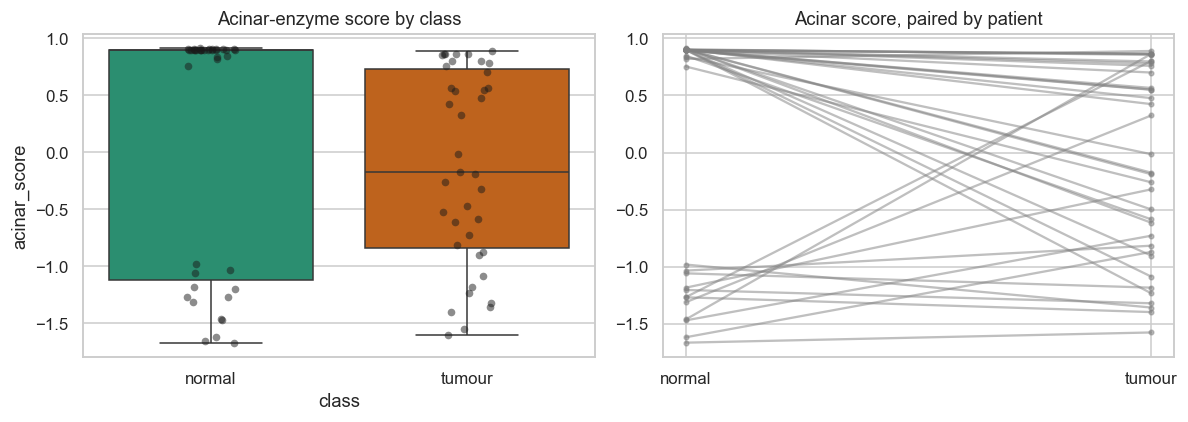

AUC of acinar score for tumour vs normal: 0.684
Patients where tumour < normal: 27 of 36


In [10]:
acinar_probes = d[(d["variance_rank"] < 100)].index   # the high-variance enzyme probes from the table
Zs = (X[acinar_probes] - X_train[acinar_probes].mean()) / X_train[acinar_probes].std()
score = Zs.mean(axis=1).rename("acinar_score")

plot_df = pd.DataFrame({"acinar_score": score, "class": y.map({0: "normal", 1: "tumour"}),
                        "patient": groups, "set": ["train" if i in set(X_train.index) else "test" for i in X.index]})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=plot_df, x="class", y="acinar_score", hue="class", palette={"normal": "#1b9e77", "tumour": "#d95f02"},
            ax=axes[0], showfliers=False, legend=False)
sns.stripplot(data=plot_df, x="class", y="acinar_score", color="k", alpha=.5, ax=axes[0])
axes[0].set_title("Acinar-enzyme score by class")

# paired view: one line per patient (first normal and first tumour array)
piv = plot_df.groupby(["patient", "class"])["acinar_score"].mean().unstack().dropna()
for _, r in piv.iterrows():
    axes[1].plot([0, 1], [r["normal"], r["tumour"]], color="grey", alpha=.5, marker="o", ms=3)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["normal", "tumour"])
axes[1].set_title("Acinar score, paired by patient")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/acinar_score.png"); plt.show()

print("AUC of acinar score for tumour vs normal:", round(roc_auc_score(y, -score), 3))
print("Patients where tumour < normal:", int((piv["tumour"] < piv["normal"]).sum()), "of", len(piv))

**Acinar score.** A composite z-score of the high-variance acinar-enzyme probes separated tumour from normal only modestly (AUC = 0.68) and was lower in the tumour in 27 of 36 patients. Normal samples were bimodal, with roughly a third showing low acinar scores comparable to tumours, and several tumours had higher acinar scores than their paired normal. This is consistent with variable acinar content (for example atrophy or fibrosis in tumour-adjacent tissue) acting as a source of within-class variation, though cellular composition was not measured directly. The score is descriptive: it was built from training-set statistics and is not used by any model.

In [11]:
top50 = {"LR":  set(lr_coef.abs().nlargest(50).index),
         "RF":  set(rf_imp.nlargest(50).index),
         "SVM": set(perm["SVM"].nlargest(50).index)}
votes = pd.Series(list(top50["LR"]) + list(top50["RF"]) + list(top50["SVM"])).value_counts()
consensus = votes[votes >= 2].index

cons_df = annotate(pd.Series(votes[consensus], name="n_models_top50")).sort_values("n_models_top50", ascending=False)
cons_df["stable_LR_folds"] = stab["LR"].reindex(cons_df.index).fillna(0).astype(int)
cons_df["stable_RF_folds"] = stab["RF"].reindex(cons_df.index).fillna(0).astype(int)
print(f"{len(cons_df)} probes are in the top 50 of at least two models")
cons_df.to_csv(f"{OUT_DIR}/consensus_features.csv")
cons_df.head(30).round(3)

26 probes are in the top 50 of at least two models


,n_models_top50,gene,log2FC,stable_LR_folds,stable_RF_folds
202729_s_at,3,LTBP1,1.938,1,2
201666_at,2,TIMP1,2.998,0,0
206224_at,2,CST1,3.489,4,0
209016_s_at,2,KRT7,3.378,2,2
206994_at,2,CST4,1.462,3,1
212236_x_at,2,JUP,2.701,0,3
218804_at,2,ANO1,3.210,0,4
201850_at,2,CAPG,2.282,0,2
235296_at,2,EIF5A2,1.511,0,0
205941_s_at,2,COL10A1,4.291,0,1


In [12]:
union_probes = sorted(set().union(*top50.values()))
u = annotate(pd.Series(1, index=union_probes, name="n")).dropna(subset=["gene"])
u = u[~u["gene"].str.match(r"^(LOC|MIR|LINC|RP\d|CT[ABCD]-|AC\d)")]     # drop non-annotated loci
genes_all  = u["gene"].drop_duplicates().tolist()
genes_up   = u[u["log2FC"] > 0]["gene"].drop_duplicates().tolist()
genes_down = u[u["log2FC"] < 0]["gene"].drop_duplicates().tolist()
print(f"{len(genes_all)} genes | up in tumour: {len(genes_up)} | down in tumour: {len(genes_down)}")
print("UP  :", ", ".join(genes_up))
print("DOWN:", ", ".join(genes_down) if genes_down else "(none)")

89 genes | up in tumour: 89 | down in tumour: 0
UP  : FGD6, POSTN, TGM2, MMP2, GPNMB, SOX4, ITGA3, TIMP1, AEBP1, CAPG, LAMC2, TACSTD2, COL1A1, ITGAV, COL1A2, TRIM29, LTBP1, AGT, SLPI, THBS2, GPRC5A, MFAP2, TPBG, COL15A1, LOXL1, DIO2, LAMA3, MMP11, WFDC2, MMP7, S100P, F3, DKK1, VCAN, MSLN, TNFRSF11B, SRPX2, STEAP1, GABBR1, COL10A1, WNT5A, NMU, CST1, CST4, CST2, KRT7, LAMB3, PRKCI, KLK10, FAP, FN1, INHBA, LAMB1, IGFBP5, C1R, JUP, SULF1, MICAL2, COL5A1, KRT6B, DKK3, CXCL5, MLPH, ANO1, NOX4, NPR3, ANTXR1, COL5A2, AMIGO2, PMEPA1, CLDN1, CTHRC1, COL8A1, ITGB6, MBOAT2, ADAMTS12, FOXQ1, PGM2L1, FAM19A5, SLC9B2, WISP1, COL3A1, KCNT2, EIF5A2, ZNF83, SDR16C5, MGP, FOXL1, SFN
DOWN: (none)


In [13]:
import gseapy as gp
LIBS = ["GO_Biological_Process_2023", "KEGG_2021_Human", "Reactome_2022"]
enrich = {}
for label, gl in [("up_in_tumour", genes_up), ("down_in_tumour", genes_down)]:
    if len(gl) < 5:
        print(f"{label}: fewer than 5 genes, skipped"); continue
    try:
        res = gp.enrichr(gene_list=gl, gene_sets=LIBS, organism="human", outdir=None).results
        res = res[res["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
        enrich[label] = res
        res.to_csv(f"{OUT_DIR}/enrichment_{label}.csv", index=False)
        print(f"\n===== {label}: {len(res)} significant terms (adj. p < 0.05) =====")
        display(res[["Gene_set", "Term", "Overlap", "Adjusted P-value", "Genes"]].head(12))
    except Exception as e:
        print(f"Enrichr unavailable ({type(e).__name__}: {e})")
        print("Offline fallback: paste the UP list into https://maayanlab.cloud/Enrichr/ and screenshot the results.")


===== up_in_tumour: 113 significant terms (adj. p < 0.05) =====


,Gene_set,Term,Overlap,Adjusted P-value,Genes
929,Reactome_2022,Extracellular Matrix Organization R-HSA-1474244,23/291,2.855483e-20,COL15A1;MMP7;LAMB3;ITGA3;MMP2;FN1;LAMC2;LAMB1;...
930,Reactome_2022,Assembly Of Collagen Fibrils And Other Multime...,12/57,2.079215e-15,COL1A1;COL15A1;COL3A1;MMP7;COL1A2;LAMB3;COL5A1...
931,Reactome_2022,Collagen Formation R-HSA-1474290,12/90,4.772607e-13,COL1A1;COL15A1;COL3A1;MMP7;COL1A2;LAMB3;COL5A1...
0,GO_Biological_Process_2023,Extracellular Matrix Organization (GO:0030198),15/176,5.612862e-13,POSTN;COL15A1;MMP7;MMP2;CAPG;ADAMTS12;LOXL1;CO...
1,GO_Biological_Process_2023,Extracellular Structure Organization (GO:0043062),13/109,5.612862e-13,POSTN;COL15A1;MMP7;MMP2;ADAMTS12;COL1A1;MMP11;...
2,GO_Biological_Process_2023,External Encapsulating Structure Organization ...,13/110,5.612862e-13,POSTN;COL15A1;MMP7;MMP2;ADAMTS12;COL1A1;MMP11;...
835,KEGG_2021_Human,ECM-receptor interaction,11/88,1.628550e-11,COL1A1;COL1A2;LAMB3;ITGA3;LAMA3;FN1;LAMC2;ITGA...
3,GO_Biological_Process_2023,Endodermal Cell Differentiation (GO:0035987),8/31,1.687648e-10,LAMB3;MMP2;LAMA3;FN1;COL8A1;ITGAV;LAMB1;INHBA
4,GO_Biological_Process_2023,Endoderm Formation (GO:0001706),8/35,3.970444e-10,LAMB3;MMP2;LAMA3;FN1;COL8A1;ITGAV;LAMB1;INHBA
932,Reactome_2022,Collagen Chain Trimerization R-HSA-8948216,8/44,1.074602e-09,COL1A1;COL15A1;COL3A1;COL1A2;COL5A1;COL5A2;COL...


down_in_tumour: fewer than 5 genes, skipped


In [14]:
rng = np.random.default_rng(SEED)
y_perm = pd.Series(rng.permutation(y_train.values), index=y_train.index)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# WRONG: pick the 200 "best" probes using ALL labels, then cross-validate
Xs = SelectKBest(f_classif, k=200).fit_transform(StandardScaler().fit_transform(X_train), y_perm)
wrong = cross_validate(LogisticRegression(C=0.1, max_iter=5000), Xs, y_perm, cv=skf, scoring="roc_auc")["test_score"]

# RIGHT: the same selection inside the pipeline, refit within each fold
right = cross_validate(make_pipe(LogisticRegression(C=0.1, max_iter=5000)), X_train, y_perm,
                       cv=skf, scoring="roc_auc", n_jobs=1)["test_score"]

print(f"Shuffled labels | selection BEFORE CV (leaky): AUC = {wrong.mean():.3f}")
print(f"Shuffled labels | selection INSIDE the pipeline: AUC = {right.mean():.3f}")

Shuffled labels | selection BEFORE CV (leaky): AUC = 0.976
Shuffled labels | selection INSIDE the pipeline: AUC = 0.482


In [15]:
pipe_lr = clone(best_models["Logistic Regression"])
rand_cv = cross_validate(pipe_lr, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                         scoring="roc_auc", n_jobs=1)["test_score"]
grp_cv  = cross_validate(pipe_lr, X_train, y_train, groups=g_train, cv=cv5,
                         scoring="roc_auc", n_jobs=1)["test_score"]
print(f"Random StratifiedKFold (ignores patients): AUC = {rand_cv.mean():.3f} ± {rand_cv.std():.3f}")
print(f"Patient-grouped CV                       : AUC = {grp_cv.mean():.3f} ± {grp_cv.std():.3f}")

Random StratifiedKFold (ignores patients): AUC = 0.954 ± 0.050
Patient-grouped CV                       : AUC = 0.963 ± 0.020


observed AUC = 0.963 | null mean = 0.523 | max null = 0.780 | p <= 0.032


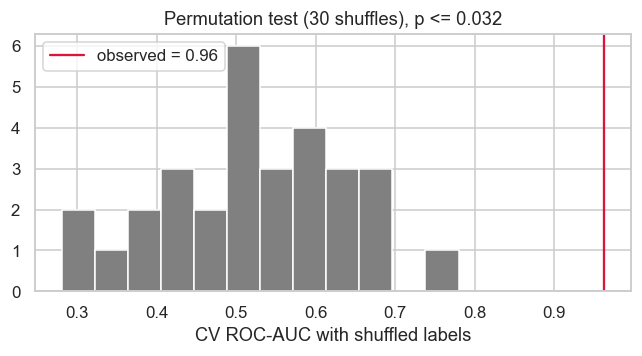

In [16]:
null = []
for i in range(30):
    yp = rng.permutation(y_train.values)
    null.append(cross_validate(pipe_lr, X_train, yp, groups=g_train, cv=cv5,
                               scoring="roc_auc", n_jobs=1)["test_score"].mean())
obs = grp_cv.mean()
pval = (1 + np.sum(np.array(null) >= obs)) / (1 + len(null))
print(f"observed AUC = {obs:.3f} | null mean = {np.mean(null):.3f} | max null = {np.max(null):.3f} | p <= {pval:.3f}")

plt.figure(figsize=(6, 3.4)); plt.hist(null, bins=12, color="grey")
plt.axvline(obs, color="crimson", label=f"observed = {obs:.2f}")
plt.xlabel("CV ROC-AUC with shuffled labels"); plt.legend()
plt.title(f"Permutation test (30 shuffles), p <= {pval:.3f}")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/permutation_test.png"); plt.show()

In [17]:
import importlib, platform
print("Python", platform.python_version(), "|", platform.platform())
for lib in ["numpy", "pandas", "scipy", "sklearn", "matplotlib", "seaborn", "GEOparse", "gseapy"]:
    try: print(f"{lib:12s}", importlib.import_module(lib).__version__)
    except Exception: print(f"{lib:12s} not available")
print("\nFiles in ./outputs:", sorted(os.listdir(OUT_DIR)))

Python 3.13.9 | Windows-10-10.0.19045-SP0
numpy        2.3.5
pandas       2.3.3
scipy        1.16.3
sklearn      1.7.2
matplotlib   3.10.6
seaborn      0.13.2
GEOparse     2.0.4
gseapy       1.3.1

Files in ./outputs: ['acinar_score.png', 'baseline_cv.csv', 'confusion_matrices.png', 'consensus_features.csv', 'eda_distributions.png', 'eda_pca.png', 'enrichment_up_in_tumour.csv', 'model_comparison.csv', 'permutation_test.png', 'roc_pr_curves.png', 'test_metrics.csv', 'tuned_models.joblib']


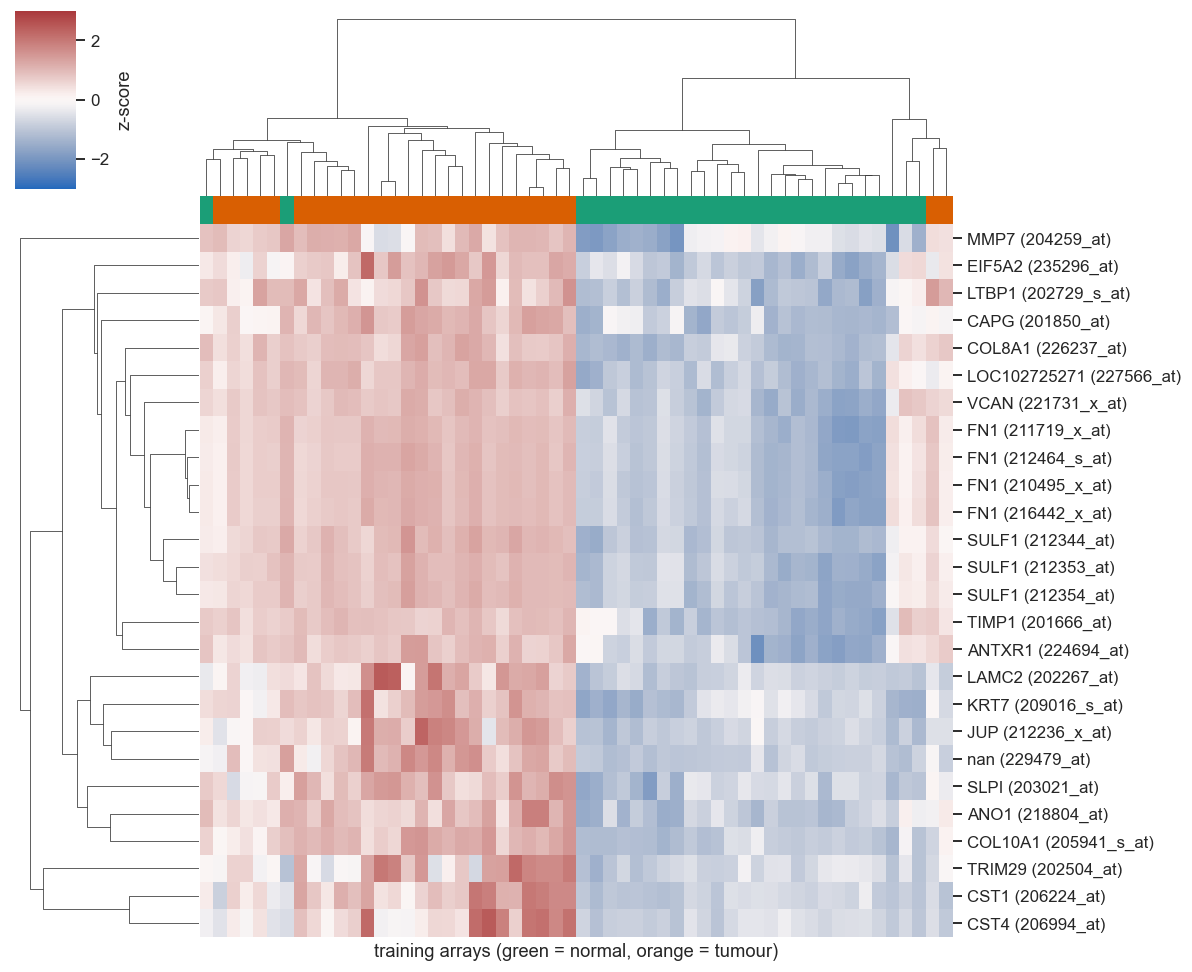

In [18]:
hm_probes = cons_df.index[:40]
Zh = (X_train[hm_probes] - X_train[hm_probes].mean()) / X_train[hm_probes].std()
Zh.columns = [f"{probe2gene.get(p, p)} ({p})" for p in hm_probes]
lut = y_train.map({0: "#1b9e77", 1: "#d95f02"})
cg = sns.clustermap(Zh.T, col_colors=lut.values, cmap="vlag", center=0, vmin=-3, vmax=3,
                    figsize=(11, 9), xticklabels=False, yticklabels=True, cbar_kws={"label": "z-score"})
cg.ax_heatmap.set_xlabel("training arrays (green = normal, orange = tumour)")
cg.savefig(f"{OUT_DIR}/consensus_heatmap.png"); plt.show()

In [19]:
from scipy.cluster.hierarchy import fcluster, linkage
Zc = Zh.values
cl = fcluster(linkage(Zc, method="average", metric="euclidean"), t=2, criterion="maxclust")
print(pd.crosstab(pd.Series(cl, index=Zh.index, name="cluster"),
                  y_train.map({0: "normal", 1: "tumour"}).rename("true class")))

true class  normal  tumour
cluster                   
1                2      26
2               26       2


In [20]:
mis = pd.DataFrame({"cluster": cl, "true": y_train.map({0: "normal", 1: "tumour"}).values,
                    "patient": g_train.values, "title": meta.loc[Zh.index, "title"].values}, index=Zh.index)
maj = mis.groupby("cluster")["true"].agg(lambda s: s.value_counts().idxmax())
display(mis[mis["true"] != mis["cluster"].map(maj)])

,cluster,true,patient,title
gsm,,,,
GSM388096,1,normal,40875,N40875
GSM388105,1,normal,51294,N51294
GSM388123,2,tumour,30277,T30277
GSM388130,2,tumour,40726,T40726
